## Logistic Regression From Scratch on Iris Dataset


#Stages ;
1. Problem Formulation
2. EDA
3. DataCleaning
4. Feature Engineering
5. Train/Test/Val Spllit
6. Model Training
7. Evaluation


#Stage 1 : Problem Formulation

- Target(Y): Species - 3 classes (Iris Serosa , Iris versicolor, Iris- virginica )
- Features : Sepallengthcm ,sepalWidthcm ,PetalLengthcm ,PetalLengthCm, PetalWidthCm
- Drop - Id - it is identifier not helping in prediction

- Unit of prediction - one flower

- Task type - Multi class classification ,via one vs rest
Since the dataset contains three classes, Logistic Regression will use One-vs-Rest (OvR) classification.

# Stage 2: Load

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/sample_data/Iris.csv')

print(df.shape)
print(df['Species'].value_counts())

(150, 5)
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


there is no class imbalance data is 50/50/50 for all target classes

In [ ]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


#Stage 3 Data Cleaning


In [ ]:
#df = df.drop(df.iloc[:,0])
df = df.drop(columns=['Id']) #Data cleaning step

#drop id col

In [ ]:
print(df.duplicated().sum()) #check for duplicate rows

#Stage 4 Feature Engineering

label encoding

In [ ]:
species_mapping={
    'Iris-setosa' :0,
    'Iris-versicolor':1,
    'Iris-virginica':2
}

df['Species_Encoded'] = df['Species'].map(species_mapping)
df.sample(5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Species_Encoded
98,5.1,2.5,3.0,1.1,Iris-versicolor,1
59,5.2,2.7,3.9,1.4,Iris-versicolor,1
43,5.0,3.5,1.6,0.6,Iris-setosa,0
66,5.6,3.0,4.5,1.5,Iris-versicolor,1
65,6.7,3.1,4.4,1.4,Iris-versicolor,1


In [ ]:
#print(df.duplicated().sum()) #dATA cleaning step to check if there is any duplicate row

3


#Stage 5: EDA

steps:
- shape and column types

1. shape and col types



In [ ]:
print (df.shape)
print(df.dtypes)

(150, 6)
SepalLengthCm      float64
SepalWidthCm       float64
PetalLengthCm      float64
PetalWidthCm       float64
Species             object
Species_Encoded      int64
dtype: object


2. Check for missing values

In [ ]:
print(df.isnull().sum())

SepalLengthCm      0
SepalWidthCm       0
PetalLengthCm      0
PetalWidthCm       0
Species            0
Species_Encoded    0
dtype: int64


There is no missing value in any col

3. Summary Statstics

In [ ]:
print(df.describe())

       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
count     150.000000    150.000000     150.000000    150.000000   
mean        5.843333      3.054000       3.758667      1.198667   
std         0.828066      0.433594       1.764420      0.763161   
min         4.300000      2.000000       1.000000      0.100000   
25%         5.100000      2.800000       1.600000      0.300000   
50%         5.800000      3.000000       4.350000      1.300000   
75%         6.400000      3.300000       5.100000      1.800000   
max         7.900000      4.400000       6.900000      2.500000   

       Species_Encoded  
count       150.000000  
mean          1.000000  
std           0.819232  
min           0.000000  
25%           0.000000  
50%           1.000000  
75%           2.000000  
max           2.000000  


every feature has 150 values, no missing values


4. Class Separability Visualization

 Extra check for classification (not required in regression

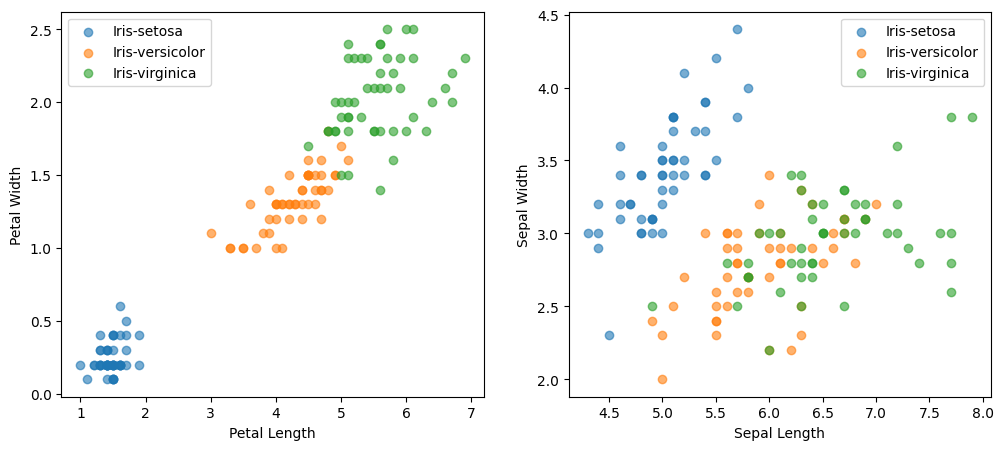

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))

for species in df['Species'].unique():
    subset = df[df['Species'] == species]
    axes[0].scatter(subset['PetalLengthCm'], subset['PetalWidthCm'], label=species, alpha=0.6)
    axes[1].scatter(subset['SepalLengthCm'], subset['SepalWidthCm'], label=species, alpha=0.6)

axes[0].set_xlabel('Petal Length'); axes[0].set_ylabel('Petal Width'); axes[0].legend()
axes[1].set_xlabel('Sepal Length'); axes[1].set_ylabel('Sepal Width'); axes[1].legend()
plt.show()

- Petal length vs Petal width plot
  - setos is completely separate from other 2 - forms it's own tight cluster
  
  - versicolor and virginica are close together , few overlap in middle still separable

  - all 3 classes are separated well by petal features

- Sepal Length vs Sepal Width plot:
  - all 3 species overlap with eachother heavily , no clean clusters
  - setosa is loosely separated but other 2 classes are almost mixed together , hard to tell apart

Petal features are more useful than ssepal ones so model uring training would give them higher weights than sepal features  
setosa should be easy to classify than other 2 classes as it is cleanly separated  

5. Outliers (using box plot)


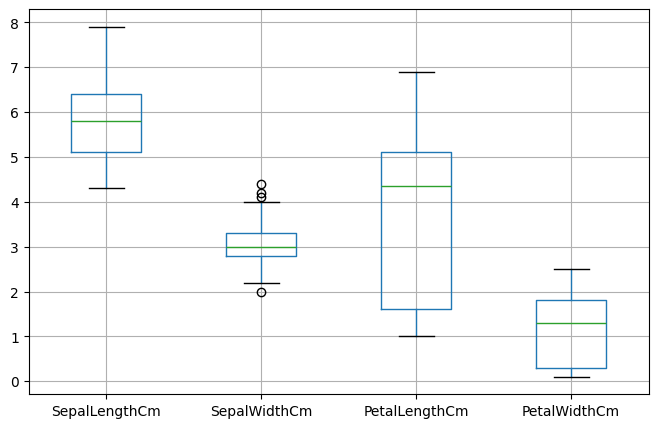

In [ ]:
import matplotlib.pyplot as plt

df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']].boxplot(figsize=(8,5))
plt.show()

6. Correlation
### Correlation can be interpreted as:

#Strength:
- gretaer absolute value of corr coeff the stronger the relationship
- coeff between -1 and 1 are perfectly colinear

- coeff = zero represents no linear relationship (one var increase doesn't increase or decrease other var )

- as r approaches -1  to +1 then ,the strength of relationship increases and the data points fall closer to line

#- Direction

- The sign of corr coeff reprensents the direction of relationship.
- +ve coeff shows direct relationship increse of one var increase of other var and vice versa

- -ve coeff represents inverse relationship , neg relation produces a downward slope



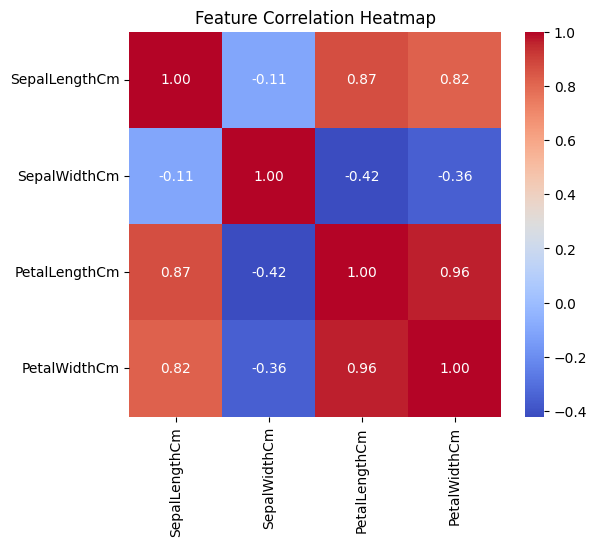

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

#Stage 5 : Train/Val/Test Split

In [ ]:
X = df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']].values
y_setosa = (df['Species_Encoded'] == 0).astype(int).values.reshape(-1,1)
y_versicolor = (df['Species_Encoded'] == 1).astype(int).values.reshape(-1,1)
y_virginica = (df['Species_Encoded'] == 2).astype(int).values.reshape(-1,1)

In [ ]:
from sklearn.model_selection import train_test_split

#60 % train
X_train,X_temp,y_setosa_train,y_setosa_temp,y_versicolor_train,y_versicolor_temp,y_virginica_train,y_virginica_temp = train_test_split(X,y_setosa,y_versicolor,y_virginica,test_size = 0.4,random_state=42)

# 20 % test 20% val
X_val,X_test,y_setosa_val,y_setosa_test,y_versicolor_val,y_versicolor_test,y_virginica_val,y_virginica_test = train_test_split(X_temp,y_setosa_temp, y_versicolor_temp,
    y_virginica_temp,
    test_size=0.5,
    random_state=42)

stage 5b : Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



In [ ]:
print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)
print(y_setosa_train.shape, y_setosa_val.shape, y_setosa_test.shape)

(90, 4) (30, 4) (30, 4)
(90, 1) (30, 1) (30, 1)


#Stage 6 : Logistic Regression Scratch

- Reusable Training Function

In [ ]:
def sigmoid(z):
  return 1/(1+np.exp(-z))


def compute_cross_entropy(y_true,y_pred):
  epsilon = 1e-10
  return -np.mean(y_true * np.log(y_pred+epsilon) + (1-y_true)*np.log(1-y_pred+epsilon))

  # Add a small epsilon to avoid log(0),
  # keeping the loss finite and preventing numerical errors during training.


def train_logistic_regression(X,y,alpha = 0.1,epochs = 1000):

  n_features = X.shape[1]

  w= np.zeros((n_features,1))
  b=0.0


  loss_history= []

  for epoch in range(epochs):

    z = X @ w +b

    y_pred = sigmoid(z)

    loss = compute_cross_entropy(y,y_pred)
    loss_history.append(loss)

    gradient_w = X.T @ (y_pred - y) / X.shape[0]
    gradient_b = np.mean(y_pred- y)

    w = w- alpha * gradient_w
    b = b-alpha * gradient_b
  return w,b,loss_history





In [ ]:
w_setosa,b_setosa,loss_setosa = train_logistic_regression(X_train_scaled,y_setosa_train)

w_versicolor,b_versicolor,loss_versicolor = train_logistic_regression(X_train_scaled,y_versicolor_train)

w_virginica,b_virginica,loss_virginica = train_logistic_regression(X_train_scaled,y_virginica_train)

print("Setosa initial loss:", loss_setosa[0])
print("Versicolor initial loss:",loss_versicolor[0])
print("Virginica initial loss:",loss_virginica[0])
print("\n")
print("Setosa final loss:", loss_setosa[-1])
print("Versicolor final loss:",loss_versicolor[-1])
print("Virginica final loss:",loss_virginica[-1])

#

Setosa initial loss: 0.6931471803599453
Versicolor initial loss: 0.6931471803599453
Virginica initial loss: 0.6931471803599453


Setosa final loss: 0.013140050866793786
Versicolor final loss: 0.48776118030979354
Virginica final loss: 0.13932248209781983


Initially when w= 0, b=0 , z =0 If every y_pred=0.5 for all samples, what does cross-entropy loss compute for a 50/50-ish split of y=0/y=1?
-log(0.5) = 0.693




- Combining 3 classifiers -
# OVR voting Step

In [ ]:
def predict_ovr(X,w_setosa,b_setosa,w_versicolor,b_versicolor,w_virginica,b_virginica):
  prob_setosa = sigmoid(X @ w_setosa + b_setosa)
  prob_versicolor = sigmoid(X @ w_versicolor +b_versicolor)
  prob_virginica = sigmoid(X @ w_virginica + b_virginica)

   # stack all three probability columns side by side: shape (N, 3)
  all_probs = np.hstack([prob_setosa, prob_versicolor, prob_virginica])

    # pick the class (column index) with the highest probability, for each row
  predictions = np.argmax(all_probs, axis=1)

  return predictions,all_probs

1. Run all 3 models on the same input -> get 3 separate probabilities
   (how confident each model is that this row is ITS class)
2. Stack those 3 numbers side by side per row (np.hstack) -> shape (N, 3)
3. Pick whichever of the 3 numbers is highest, per row (np.argmax, axis=1)
   -> that model's class becomes the final prediction

In [ ]:
train_predictions, train_probs = predict_ovr(X_train_scaled, w_setosa, b_setosa, w_versicolor, b_versicolor, w_virginica, b_virginica)
val_predictions, val_probs = predict_ovr(X_val_scaled, w_setosa, b_setosa, w_versicolor, b_versicolor, w_virginica, b_virginica)

print(val_predictions[:10])


[2 2 2 1 0 1 0 2 0 0]


Interprest ;
resolve the gap y is that it the way it is

ood first sign the model isn't collapsed onto a
single always-guess answer.

In [ ]:
y_val_true_stack = np.hstack([y_setosa_val, y_versicolor_val, y_virginica_val])
y_val_true = np.argmax(y_val_true_stack, axis=1)

In [ ]:
print("True:      ", y_val_true[:10])
print("Predicted: ", val_predictions[:10])

True:       [2 2 2 1 0 1 0 1 0 0]
Predicted:  [2 2 2 1 0 1 0 2 0 0]


#Evaluation metrics



In [ ]:
def compute_confusion_counts(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn

def accuracy(y_true, y_pred):
    tp, tn, fp, fn = compute_confusion_counts(y_true, y_pred)
    return (tp + tn) / (tp + tn + fp + fn)

def precision(y_true, y_pred):
    tp, tn, fp, fn = compute_confusion_counts(y_true, y_pred)
    return tp / (tp + fp)

def recall(y_true, y_pred):
    tp, tn, fp, fn = compute_confusion_counts(y_true, y_pred)
    return tp / (tp + fn)

def f1_score(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * (p * r) / (p + r)

In [ ]:
print("Overall validation accuracy:", accuracy(y_val_true, val_predictions))
print("Overall validation precision:", precision(y_val_true, val_predictions))
print("Overall validation recall:", recall(y_val_true, val_predictions))
print("Overall validation f1 score:", f1_score(y_val_true, val_predictions))

Overall validation accuracy: 1.0
Overall validation precision: 1.0
Overall validation recall: 1.0
Overall validation f1 score: 1.0


In [ ]:
print(np.sum(y_val_true == val_predictions))
print(len(y_val_true))

29
30


In [ ]:
tp, tn, fp, fn = compute_confusion_counts(y_val_true, val_predictions)
print(tp, tn, fp, fn)
print(tp + tn + fp + fn)

5 12 0 0
17


In [ ]:
def accuracy_multiclass(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

print("Overall validation accuracy:", accuracy_multiclass(y_val_true, val_predictions))

Overall validation accuracy: 0.9666666666666667


In [ ]:
y_versicolor_val_flat = y_versicolor_val.flatten()
versicolor_pred_binary = (val_probs[:,1] >= 0.5).astype(int)
print("Versicolor precision:", precision(y_versicolor_val_flat, versicolor_pred_binary))
print("Versicolor recall:", recall(y_versicolor_val_flat, versicolor_pred_binary))
print("Versicolor f1:", f1_score(y_versicolor_val_flat, versicolor_pred_binary))

Versicolor precision: 0.4
Versicolor recall: 0.3333333333333333
Versicolor f1: 0.3636363636363636


In [ ]:
y_setosa_val_flat = y_setosa_val.flatten()
setosa_pred_binary = (val_probs[:,0] >= 0.5).astype(int)
print("Setosa precision:", precision(y_setosa_val_flat, setosa_pred_binary))
print("Setosa recall:", recall(y_setosa_val_flat, setosa_pred_binary))
print("Setosa f1:", f1_score(y_setosa_val_flat, setosa_pred_binary))


Setosa precision: 1.0
Setosa recall: 1.0
Setosa f1: 1.0


In [ ]:

y_virginica_val_flat = y_virginica_val.flatten()
virginica_pred_binary = (val_probs[:,2] >= 0.5).astype(int)
print("Virginica precision:", precision(y_virginica_val_flat, virginica_pred_binary))
print("Virginica recall:", recall(y_virginica_val_flat, virginica_pred_binary))
print("Virginica f1:", f1_score(y_virginica_val_flat, virginica_pred_binary))

Virginica precision: 1.0
Virginica recall: 1.0
Virginica f1: 1.0


## Final Test Set Evaluation

In [ ]:
y_test_true_stack = np.hstack([y_setosa_test, y_versicolor_test, y_virginica_test])
y_test_true = np.argmax(y_test_true_stack, axis=1)

test_predictions, test_probs = predict_ovr(X_test_scaled, w_setosa, b_setosa, w_versicolor, b_versicolor, w_virginica, b_virginica)

print("Test accuracy:", accuracy_multiclass(y_test_true, test_predictions))

Test accuracy: 0.8666666666666667


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
